In [1]:
import pandas as pd 

In [2]:
ranking_df = pd.read_csv("../processed_data/best_crop_net_profit_ranking.csv")

print("Columns in file:")
print(ranking_df.columns)

ranking_df.head()


Columns in file:
Index(['profit_rank', 'crop', 'predicted_yield', 'modal_price',
       'expected_revenue', 'cost_per_hectare', 'net_profit'],
      dtype='object')


,profit_rank,crop,predicted_yield,modal_price,expected_revenue,cost_per_hectare,net_profit
0,1,Black pepper,57.995652,80000.0,4.639652e+06,70000.0,4.569652e+06
1,2,Black pepper,57.995652,68000.0,3.943704e+06,70000.0,3.873704e+06
2,3,Black pepper,57.995652,67100.0,3.891508e+06,70000.0,3.821508e+06
3,4,Black pepper,57.995652,66500.0,3.856711e+06,70000.0,3.786711e+06
4,5,Black pepper,57.995652,66000.0,3.827713e+06,70000.0,3.757713e+06


In [3]:
def get_top_5_crops(state, district):
    
    filtered = ranking_df[
        (ranking_df["State"] == state) &
        (ranking_df["District"] == district)
    ]
    
    if filtered.empty:
        return "No data found for this State/District"
    
    filtered = filtered.sort_values(
        "Expected_Profit",
        ascending=False
    )
    
    return filtered[["Commodity", "Expected_Profit"]].head(5)

In [4]:
import pandas as pd

ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")

# Clean just in case
ranking_df.columns = ranking_df.columns.str.strip().str.lower()

print("Columns:")
print(ranking_df.columns)

ranking_df.head()

Columns:
Index(['state', 'district', 'crop', 'predicted_yield', 'modal_price',
       'expected_revenue', 'rank'],
      dtype='object')


,state,district,crop,predicted_yield,modal_price,expected_revenue,rank
0,Andhra Pradesh,Visakhapatnam,Turmeric,49.939109,11000.0,549330.203632,1.0
1,Andhra Pradesh,Visakhapatnam,Turmeric,48.592510,11000.0,534517.605607,2.0
2,Andhra Pradesh,Visakhapatnam,Turmeric,46.915402,11000.0,516069.422809,3.0
3,Andhra Pradesh,Visakhapatnam,Turmeric,46.670182,11000.0,513371.997936,4.0
4,Andhra Pradesh,Visakhapatnam,Turmeric,45.293171,11000.0,498224.875655,5.0


In [5]:
def get_top_5_crops(state, district):
    
    filtered = ranking_df[
        (ranking_df["state"] == state) &
        (ranking_df["district"] == district)
    ]
    
    if filtered.empty:
        return "No data found for this State/District"
    
    # Sort by rank (ascending → rank 1 is best)
    filtered = filtered.sort_values("rank")
    
    return filtered[
        ["crop", "predicted_yield", "modal_price", "expected_revenue", "rank"]
    ].head(5)

In [6]:
state_input = "Maharashtra"
district_input = "Pune"

result = get_top_5_crops(state_input, district_input)

print("\n=== TOP 5 CROPS ===")
display(result)


=== TOP 5 CROPS ===


,crop,predicted_yield,modal_price,expected_revenue,rank
1867,Rice,50.786661,9500.0,482473.283135,1.0
1868,Rice,50.593709,9500.0,480640.232939,2.0
1869,Rice,50.550726,9500.0,480231.897343,3.0
1870,Rice,47.992160,9500.0,455925.522831,4.0
1871,Rice,46.726675,9500.0,443903.409291,5.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")
ranking_df.columns = ranking_df.columns.str.strip().str.lower()
print(ranking_df)

               state            district      crop  predicted_yield  \
0     Andhra Pradesh       Visakhapatnam  Turmeric        49.939109   
1     Andhra Pradesh       Visakhapatnam  Turmeric        48.592510   
2     Andhra Pradesh       Visakhapatnam  Turmeric        46.915402   
3     Andhra Pradesh       Visakhapatnam  Turmeric        46.670182   
4     Andhra Pradesh       Visakhapatnam  Turmeric        45.293171   
...              ...                 ...       ...              ...   
5177     West Bengal  Sounth 24 Parganas      Rice        36.139839   
5178     West Bengal  Sounth 24 Parganas      Rice        35.149150   
5179     West Bengal  Sounth 24 Parganas      Rice        35.149150   
5180     West Bengal  Sounth 24 Parganas      Rice        34.937315   
5181     West Bengal  Sounth 24 Parganas      Rice        34.937315   

      modal_price  expected_revenue  rank  
0         11000.0     549330.203632   1.0  
1         11000.0     534517.605607   2.0  
2         11000


=== TOP 5 CROPS ===


,crop,expected_revenue,rank
12,Maize,132365.832782,1.0
13,Maize,128537.201456,2.0
14,Maize,115097.431057,3.0
15,Maize,102970.302059,4.0
16,Maize,76567.869157,5.0


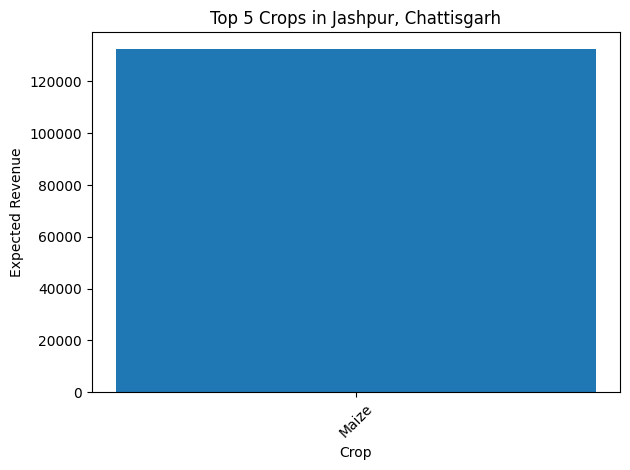

In [14]:
state_input = input("Enter State: ")
district_input = input("Enter District: ")

filtered = ranking_df[
    (ranking_df["state"] == state_input) &
    (ranking_df["district"] == district_input)
]

if filtered.empty:
    print("No data found.")
else:
    top5 = filtered.sort_values("rank").head(5)
    
    print("\n=== TOP 5 CROPS ===")
    display(top5[["crop", "expected_revenue", "rank"]])

    plt.figure()
    plt.bar(top5["crop"], top5["expected_revenue"])
    plt.xticks(rotation=45)
    plt.xlabel("Crop")
    plt.ylabel("Expected Revenue")
    plt.title(f"Top 5 Crops in {district_input}, {state_input}")
    plt.tight_layout()
    plt.show()